# 📊 Exploratory Data Analysis (EDA) - Bitcoin Price Prediction

This notebook contains:
- Data loading
- Basic statistical analysis
- Trend visualization
- Feature understanding
- Volatility analysis

Goal: Understand Bitcoin price behavior before building ML models.

In [172]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
# Load dataset
df = pd.read_csv("btc_data.csv")
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2018-01-01,13657.2001953125,14112.2001953125,13154.7001953125,14112.2001953125,10291200000
3,2018-01-02,14982.099609375,15444.599609375,13163.599609375,13625.0,16846600192
4,2018-01-03,15201.0,15572.7998046875,14844.5,14978.2001953125,16871900160


In [174]:
df.shape

(2924, 6)

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2924 entries, 0 to 2923
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   2924 non-null   object
 1   Close   2923 non-null   object
 2   High    2923 non-null   object
 3   Low     2923 non-null   object
 4   Open    2923 non-null   object
 5   Volume  2923 non-null   object
dtypes: object(6)
memory usage: 137.2+ KB


In [176]:
df.describe()

,Price,Close,High,Low,Open,Volume
count,2924,2923,2923,2923,2923,2923
unique,2924,2922,2922,2922,2923,2923
top,2025-12-31,6741.75,6536.919921875,27375.6015625,88429.5859375,33830210616
freq,1,2,2,2,1,1


In [177]:
df.isnull().sum()

,0
Price,0
Close,1
High,1
Low,1
Open,1
Volume,1


In [178]:
# Drop the first two metadata rows (index 0 and 1)
df = df.iloc[2:].copy()

# Rename the 'Price' column to 'Date'
df = df.rename(columns={'Price': 'Date'})

# Convert the 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the DataFrame index
df = df.set_index('Date')

# Convert other columns to numeric, coercing errors to NaN
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df

,Close,High,Low,Open,Volume
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072
...,...,...,...,...,...
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849


## 📈 Bitcoin Price Trend Visualization
We analyze how Bitcoin closing price changes over time.

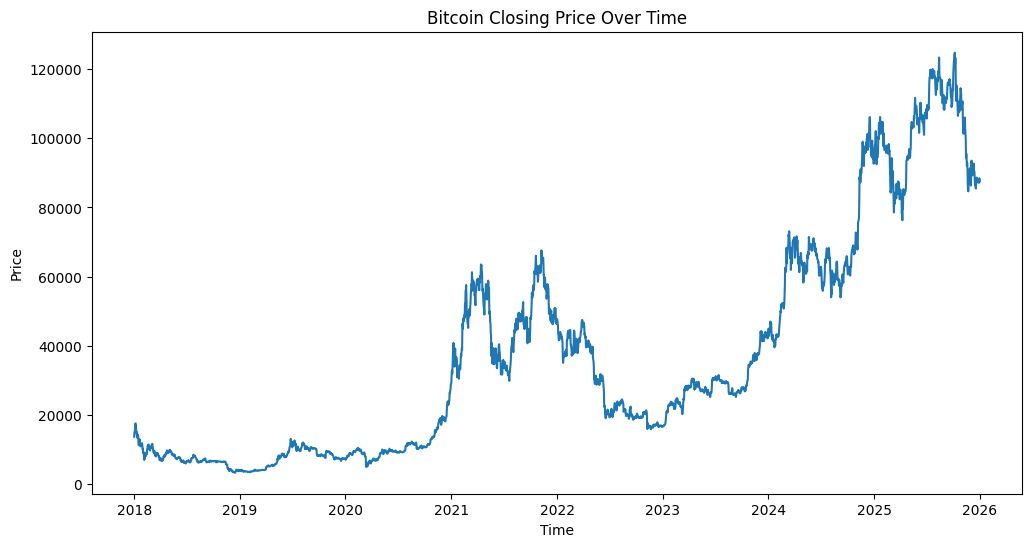

In [179]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## 📊 Trading Volume Analysis
Volume shows market activity and investor interest.

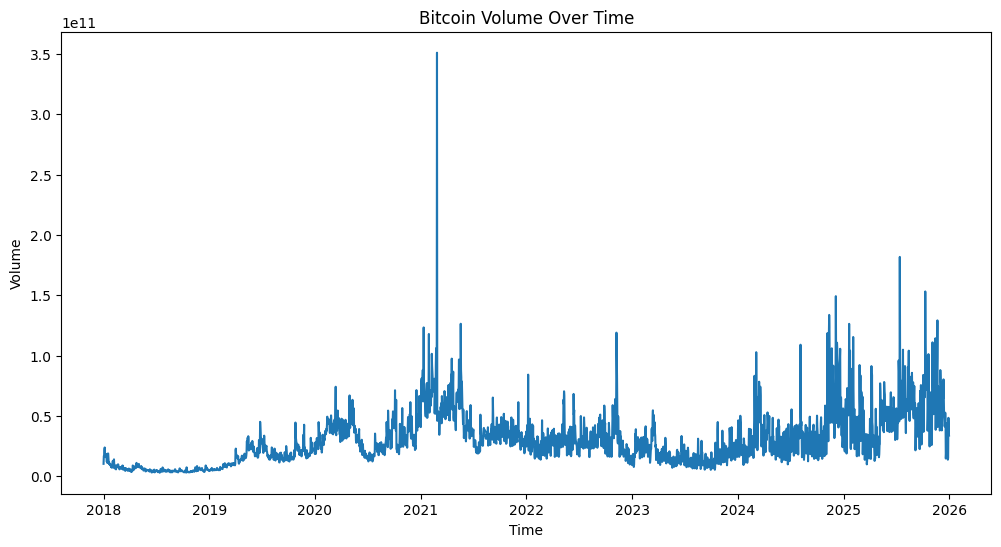

In [180]:
plt.figure(figsize=(12,6))
plt.plot(df['Volume'])
plt.title("Bitcoin Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.show()

## 📉 Moving Averages (Trend Smoothing)
Moving averages help identify market trends.

In [181]:
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()

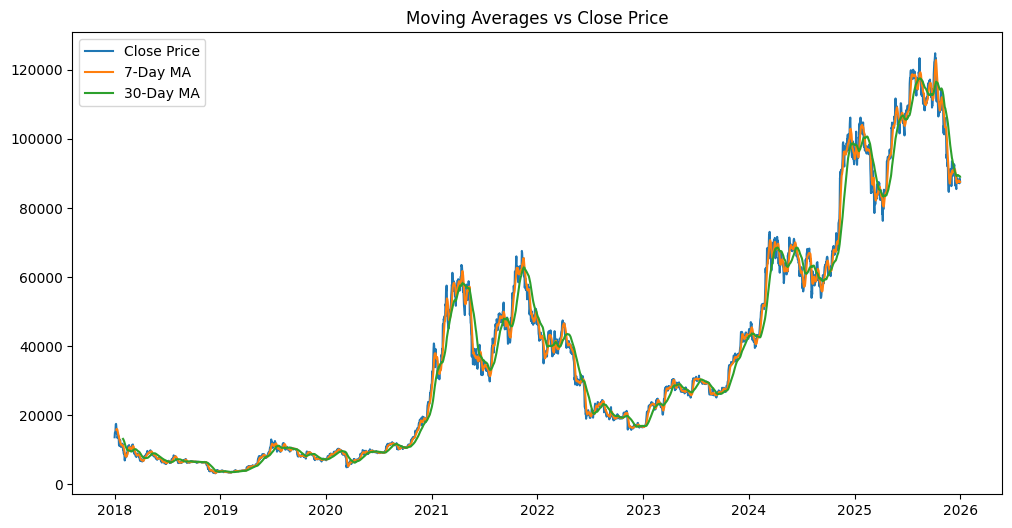

In [182]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA7'], label='7-Day MA')
plt.plot(df['MA30'], label='30-Day MA')
plt.legend()
plt.title("Moving Averages vs Close Price")
plt.show()

## 📉 Daily Returns (Volatility Analysis)
This shows how much price changes daily.

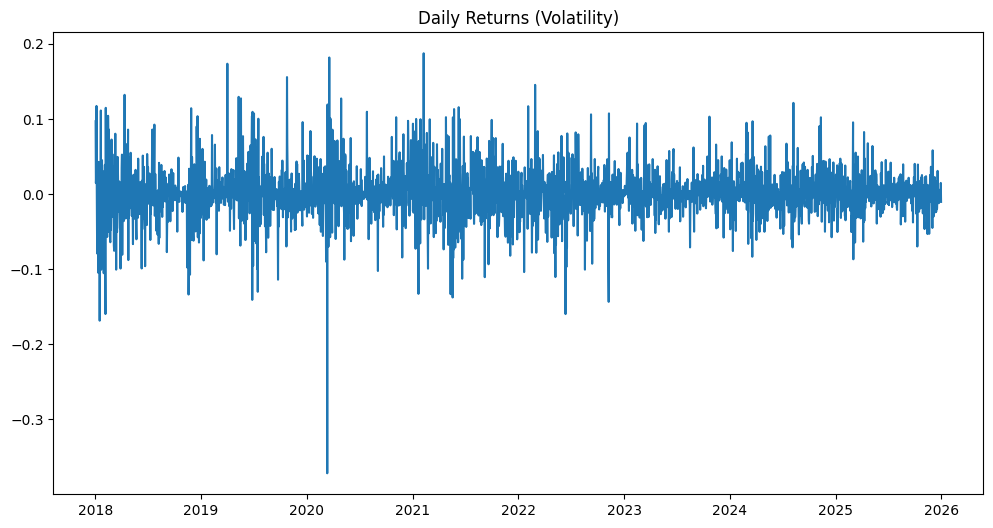

In [183]:
df['Returns'] = df['Close'].pct_change()

plt.figure(figsize=(12,6))
plt.plot(df['Returns'])
plt.title("Daily Returns (Volatility)")
plt.show()

## 🔗 Feature Correlation Analysis
We check how strongly features are related.

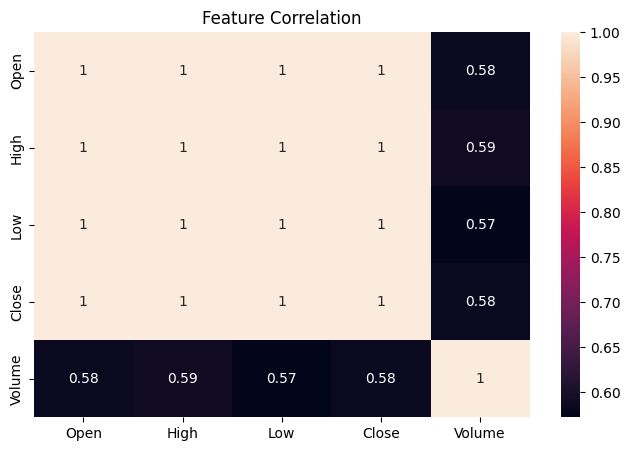

In [184]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

## 📌 Key Observations

Based on our Exploratory Data Analysis, key insights are:

*   **Market Trend Behavior**: Moving averages (MA7, MA30) define Bitcoin's price trends (uptrend: MA7 > MA30; downtrend: MA7 < MA30), showing periods of growth, decline, and consolidation.

*   **Volatility Level**: "Daily Returns" chart reveals high/low volatility periods, crucial for risk assessment.

*   **Volume Impact**: "Bitcoin Volume Over Time" indicates trading activity. High volume confirms price movements; low volume suggests indecision.

*   **Feature Relationships**: "Feature Correlation" heatmap shows strong positive correlation among 'Open', 'High', 'Low', 'Close' prices. 'Volume' has a weaker correlation, but still impacts market activity.

